# Visualisation Notebook

In [9]:
import torch
import json
import re
import gc
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from collections import defaultdict
from datasets import load_dataset
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM
from llm_wrapper import DGQModelWrapper

LETTERS = "ABCDEFGHIJ"

In [10]:
# Model to test
model_name = "google/gemma-3-4b-it"

# Outlier Map
outlier_map_path = "outlier_map_google_gemma-3-4b-it-0.05.json"
with open(outlier_map_path, "r") as f:
    outlier_map = json.load(f)

device = "cuda"

In [11]:
# Load the model and run a calibration pass to capture activation magnitudes
print("Loading model...")
model = AutoModelForCausalLM.from_pretrained(model_name, dtype=torch.bfloat16)
model.to(device)
model.eval()

tokeniser = AutoTokenizer.from_pretrained(model_name)
if tokeniser.pad_token_id is None:
    tokeniser.pad_token = tokeniser.eos_token

Loading model...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [12]:
# Capture per-channel activation magnitudes using hooks
channel_max_mags = {}
hooks = []

def get_activation_hook(name):
    def hook(module, input, output):
        x = input[0].detach()
        current_max = x.abs().max(dim=0)[0].max(dim=0)[0]
        if name not in channel_max_mags:
            channel_max_mags[name] = current_max
        else:
            channel_max_mags[name] = torch.maximum(channel_max_mags[name], current_max)
    return hook

for name, module in model.named_modules():
    if isinstance(module, nn.Linear) and "lm_head" not in name:
        hooks.append(module.register_forward_hook(get_activation_hook(name)))

# Run a few representative prompts through the model
calibration_prompts = [
    "Explain quantum computing in simple terms.",
    "What is the capital of France and what is it known for?",
    "Write a Python function to sort a list using merge sort.",
    "The theory of relativity states that",
]

print("Running calibration prompts...")
with torch.no_grad():
    for prompt in tqdm(calibration_prompts):
        inputs = tokeniser(prompt, return_tensors="pt", truncation=True, max_length=512).to(device)
        _ = model(**inputs, use_cache=False)

# Clean up hooks
for hook in hooks:
    hook.remove()

print(f"Captured magnitudes for {len(channel_max_mags)} layers.")
print(f"Example layer names: {list(channel_max_mags.keys())[:3]}")

Running calibration prompts...


100%|██████████| 4/4 [00:00<00:00, 17.80it/s]

Captured magnitudes for 238 layers.
Example layer names: ['model.language_model.layers.0.self_attn.q_proj', 'model.language_model.layers.0.self_attn.k_proj', 'model.language_model.layers.0.self_attn.v_proj']


In [13]:
def plot_channel_outliers(layer_name, channel_max_mags, outlier_map, top_n_label=10, order=False, top_n=None):
    """
    Plots the max activation magnitude for each input channel of a specific layer.
    Outlier channels (from the outlier_map) are highlighted in red.
    
    Args:
        layer_name: The full layer name (e.g. 'model.language_model.layers.0.mlp.gate_proj')
        channel_max_mags: Dict of {layer_name: tensor of per-channel max magnitudes}
        outlier_map: Dict of {layer_name: list of outlier channel indices}
        top_n_label: Number of top outlier channels to label on the plot
    """
    if layer_name not in channel_max_mags:
        print(f"Layer '{layer_name}' not found in captured magnitudes.")
        print(f"Available layers (first 5): {list(channel_max_mags.keys())[:5]}")
        return
    
    mags = channel_max_mags[layer_name].cpu().float().numpy()
    outlier_indices = set(outlier_map.get(layer_name, []))
    num_channels = len(mags)
    
    # Array to track the original channel indices
    channel_indices = np.arange(num_channels)
    
    if order:
        # Sort by magnitude in descending order (highest activations first)
        sort_order = np.argsort(mags)[::-1]
        
        # Slice to top_n if provided
        if top_n is not None:
            sort_order = sort_order[:top_n]
        
        mags = mags[sort_order]
        channel_indices = channel_indices[sort_order]
        
    num_channels = len(mags)
    
    # Separate colours: red for outliers, blue for normal
    colours = ['#e74c3c' if orig_idx in outlier_indices else '#3498db' for orig_idx in channel_indices]
    alphas = [1.0 if orig_idx in outlier_indices else 0.4 for orig_idx in channel_indices]
    
    fig, ax = plt.subplots(figsize=(16, 5))
    
    # Plot all channels as a bar chart
    bars = ax.bar(range(num_channels), mags, color=colours, width=1.0, edgecolor='none')
    for bar, alpha in zip(bars, alphas):
        bar.set_alpha(alpha)
    
    # Label the top N outlier channels
    if outlier_indices:
        outlier_mags = []
        for plot_idx, orig_idx in enumerate(channel_indices):
            if orig_idx in outlier_indices:
                outlier_mags.append((orig_idx, mags[plot_idx]))
        outlier_mags.sort(key=lambda x: x[1], reverse=True)
    
    # Legend
    visible_outliers = sum(1 for idx in channel_indices if idx in outlier_indices)
    outlier_patch = mpatches.Patch(color='#e74c3c', label=f'Outlier channels ({visible_outliers})')
    normal_patch = mpatches.Patch(color='#3498db', alpha=0.4, label=f'Normal channels ({num_channels - visible_outliers})')
    ax.legend(handles=[outlier_patch, normal_patch], loc='upper right', fontsize=9)
    
    if top_n:
        suffix = f' for top {top_n} channels'
    else:
        suffix = ''

    # Formatting
    short_name = layer_name.split('model.')[-1] if 'model.' in layer_name else layer_name
    ax.set_title(f'Per-Channel Activation Magnitudes: {short_name}'+suffix, fontsize=12, fontweight='bold')
    ax.set_xlabel('Channel Index', fontsize=10)
    ax.set_ylabel('Max Activation Magnitude', fontsize=10)
    ax.set_xlim(-0.5, num_channels - 0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.show()

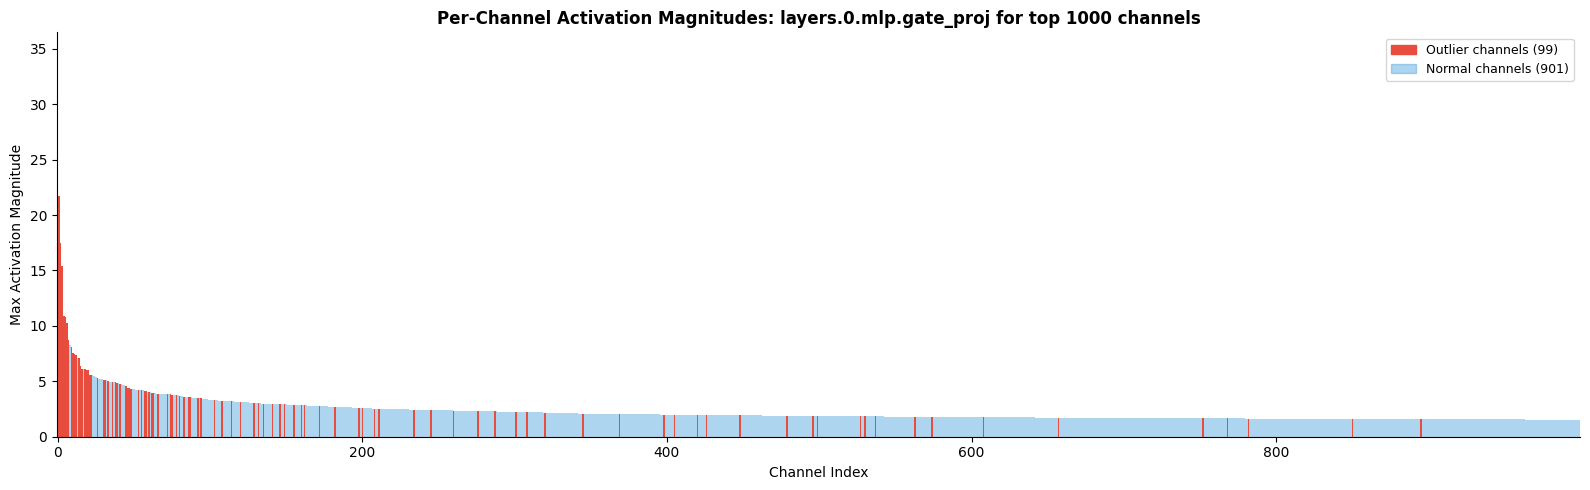

In [14]:
# Plot a specific layer — change the layer name to explore different layers
# Example layers to try:
#   model.language_model.layers.0.mlp.gate_proj
#   model.language_model.layers.0.self_attn.q_proj
#   model.language_model.layers.12.mlp.down_proj

layer_to_plot = "model.language_model.layers.0.mlp.gate_proj"
plot_channel_outliers(layer_to_plot, channel_max_mags, outlier_map, order=True, top_n=1000)

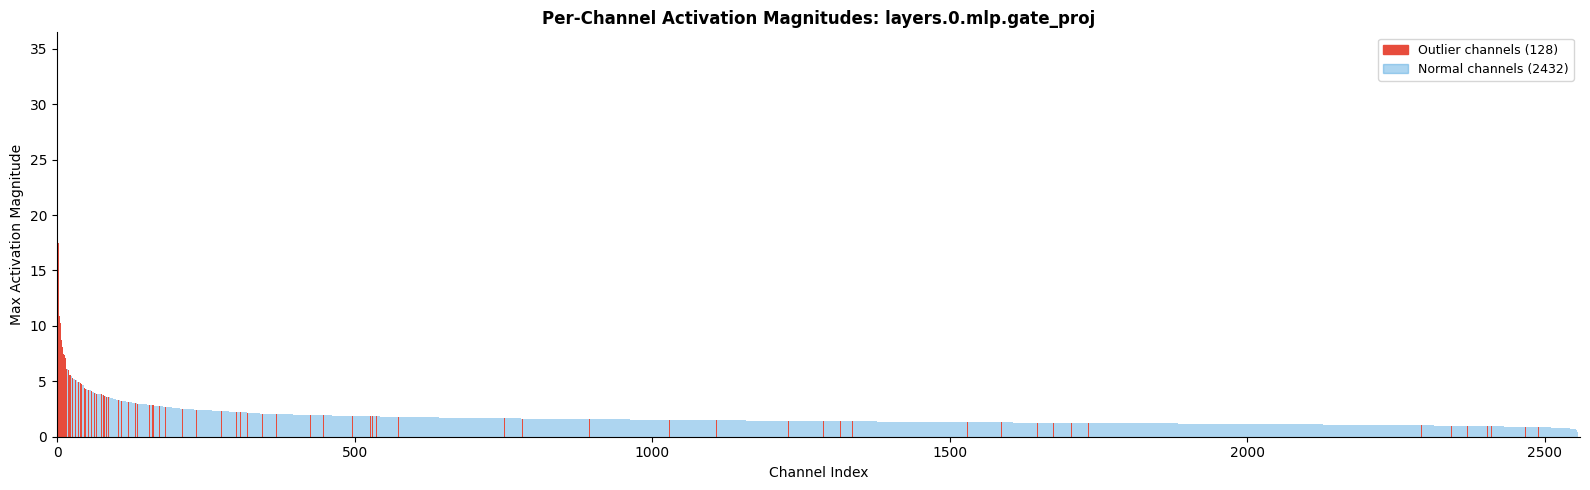

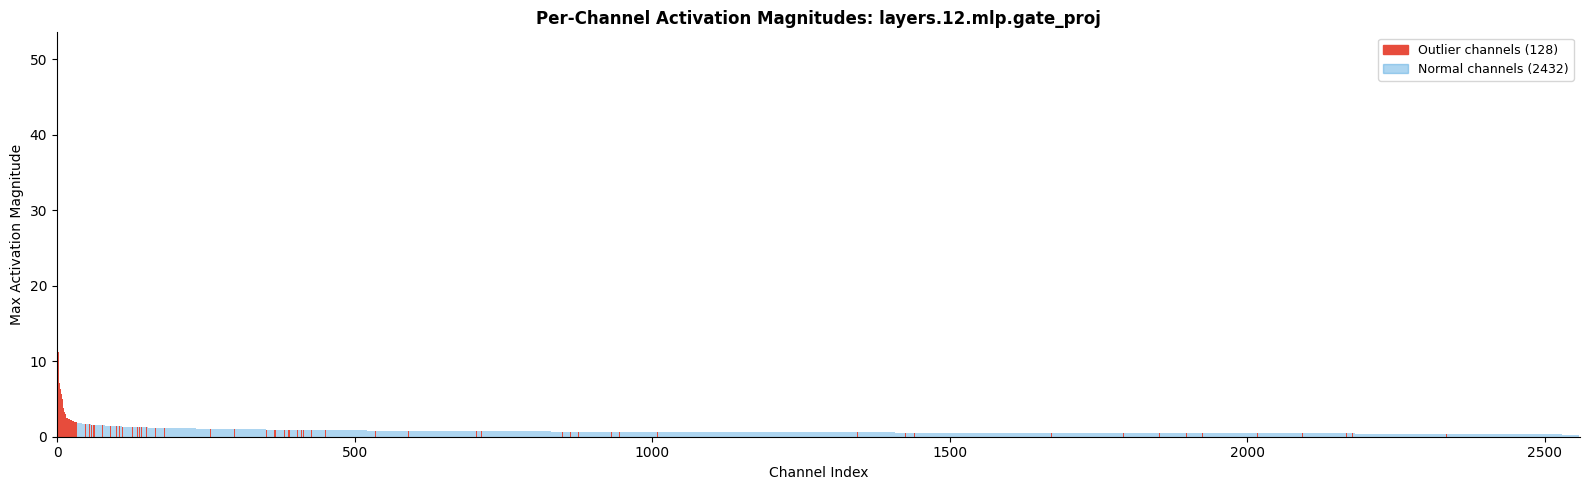

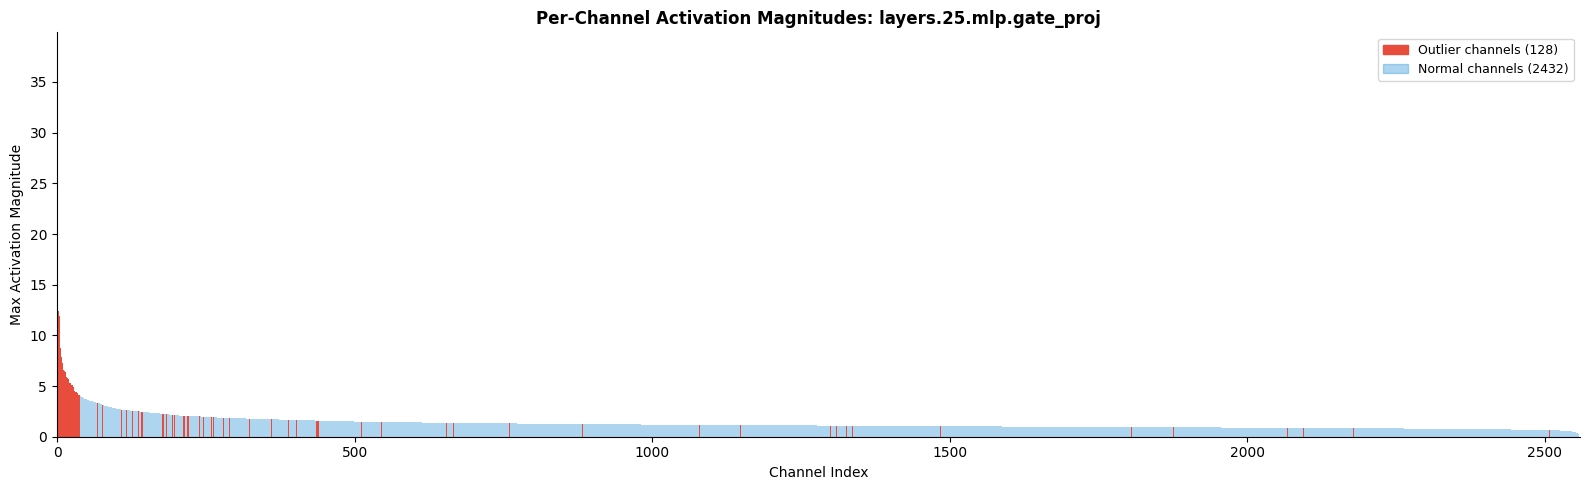

In [15]:
# Plot multiple layers side by side for comparison
layers_to_compare = [
    "model.language_model.layers.0.mlp.gate_proj",
    "model.language_model.layers.12.mlp.gate_proj",
    "model.language_model.layers.25.mlp.gate_proj",
]

for layer in layers_to_compare:
    plot_channel_outliers(layer, channel_max_mags, outlier_map, order=True)

In [16]:
# Summary: show which layers have the most extreme outliers
print(f"{'Layer':<55} {'Max Mag':>10} {'Outliers':>10} {'mean_val':>15} {'Ratio':>10}")
print("-" * 90)

layer_stats = []
for name, mags in channel_max_mags.items():
    max_val = mags.max().item()
    mean_val = mags.mean().item()
    n_outliers = len(outlier_map.get(name, []))
    ratio = max_val / mean_val if mean_val > 0 else 0
    layer_stats.append((name, max_val, mean_val, n_outliers, ratio))

# Sort by outlier-to-mean ratio (most extreme first)
layer_stats.sort(key=lambda x: x[3], reverse=True)

for name, max_val, mean_val, n_outliers, ratio in layer_stats[:20]:
    short = name.split('model.')[-1] if 'model.' in name else name
    print(f"{short:<55} {max_val:>10.1f} {n_outliers:>10} {mean_val:>15} {ratio:>10.1f}x")

Layer                                                      Max Mag   Outliers        mean_val      Ratio
------------------------------------------------------------------------------------------
layers.0.mlp.down_proj                                       225.0        512        1.140625      197.3x
layers.1.mlp.down_proj                                        13.9        512      0.45703125       30.5x
layers.2.mlp.down_proj                                        29.5        512      0.54296875       54.3x
layers.3.mlp.down_proj                                        66.0        512      0.62109375      106.3x
layers.4.mlp.down_proj                                        62.8        512        0.453125      138.5x
layers.5.mlp.down_proj                                        27.1        512        0.421875       64.3x
layers.6.mlp.down_proj                                        16.1        512      0.37890625       42.6x
layers.7.mlp.down_proj                                        